In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

%matplotlib inline
sns.set(style="darkgrid")

In [ ]:
data_train = pd.read_csv('train.csv')
data_test = pd.read_csv('test.csv')

X_train = data_train.drop(columns=['Id','SalePrice'])
X_test = data_test.drop(columns=['Id'])

y_test = pd.read_csv('sample_submission.csv')['SalePrice']
y_train = data_train['SalePrice']

In [ ]:
y_test, y_train

(0       169277.052498
 1       187758.393989
 2       183583.683570
 3       179317.477511
 4       150730.079977
             ...      
 1454    167081.220949
 1455    164788.778231
 1456    219222.423400
 1457    184924.279659
 1458    187741.866657
 Name: SalePrice, Length: 1459, dtype: float64,
 0       208500
 1       181500
 2       223500
 3       140000
 4       250000
          ...  
 1455    175000
 1456    210000
 1457    266500
 1458    142125
 1459    147500
 Name: SalePrice, Length: 1460, dtype: int64)

In [15]:
X_train.shape, X_test.shape

((1460, 79), (1459, 79))

/tmp/ipykernel_34320/375460187.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train)


<Axes: xlabel='SalePrice', ylabel='Density'>

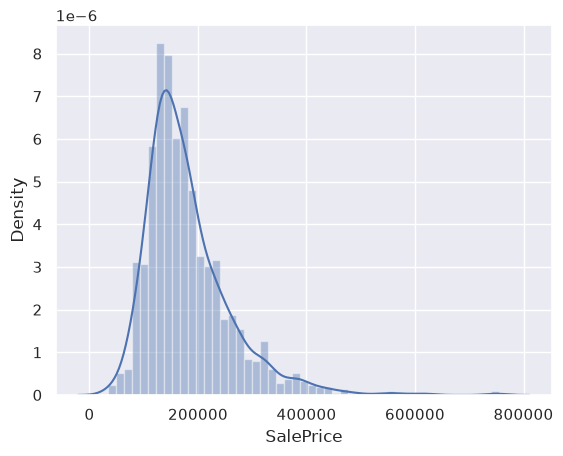

In [16]:
sns.distplot(y_train)

MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
dtype: object
MSSubClass          56.897260
LotFrontage         70.049958
LotArea          10516.828

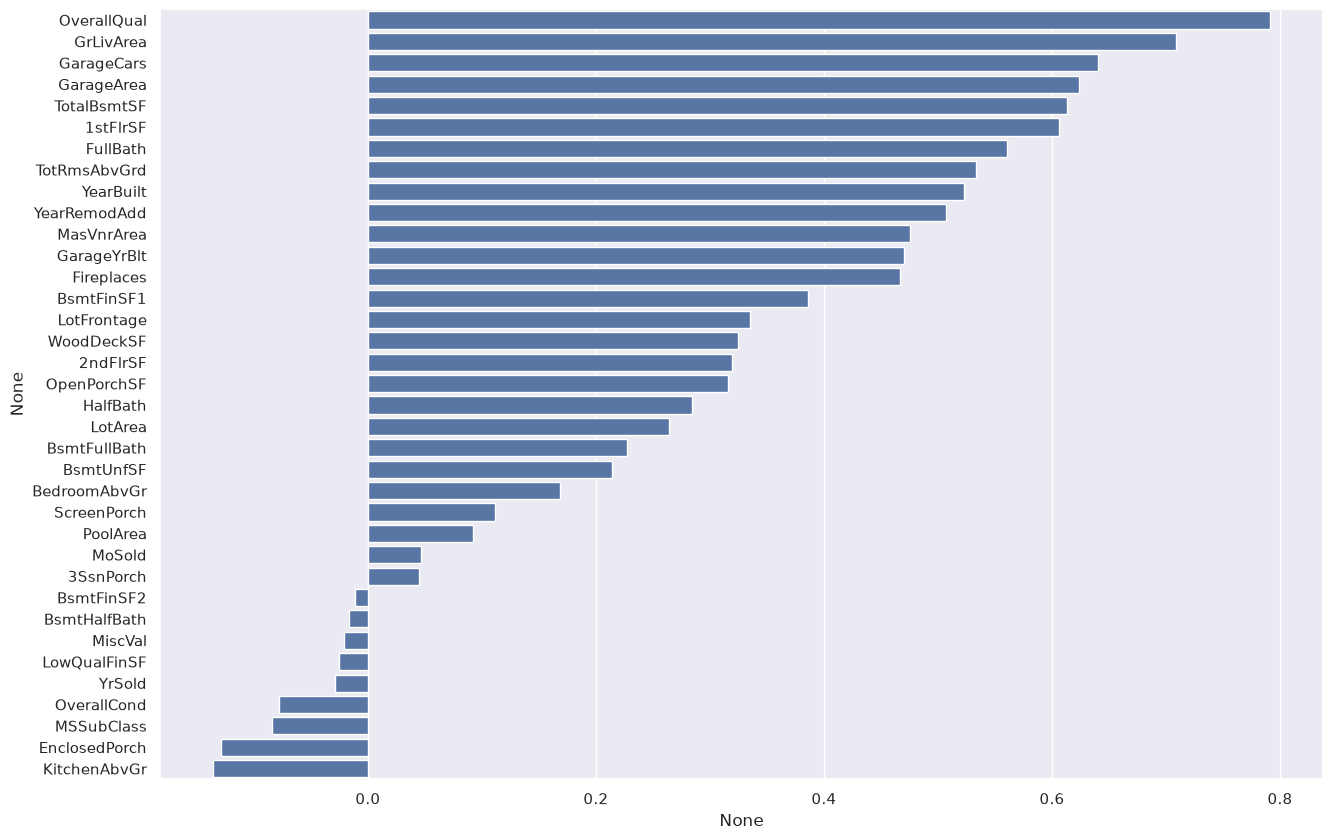

In [24]:
numeric_data = X_train.select_dtypes([np.number])
numeric_data_mean = numeric_data.mean()
numeric_features = numeric_data.columns

print(numeric_data.dtypes)
print(numeric_data_mean)
print(numeric_features)

X_train = X_train.fillna(numeric_data_mean)
X_test = X_test.fillna(numeric_data_mean)

corr = X_train[numeric_features].corrwith(y_train).sort_values(ascending=False)

plot = sns.barplot(y=corr.index, x=corr)
plot.figure.set_size_inches(15,10)

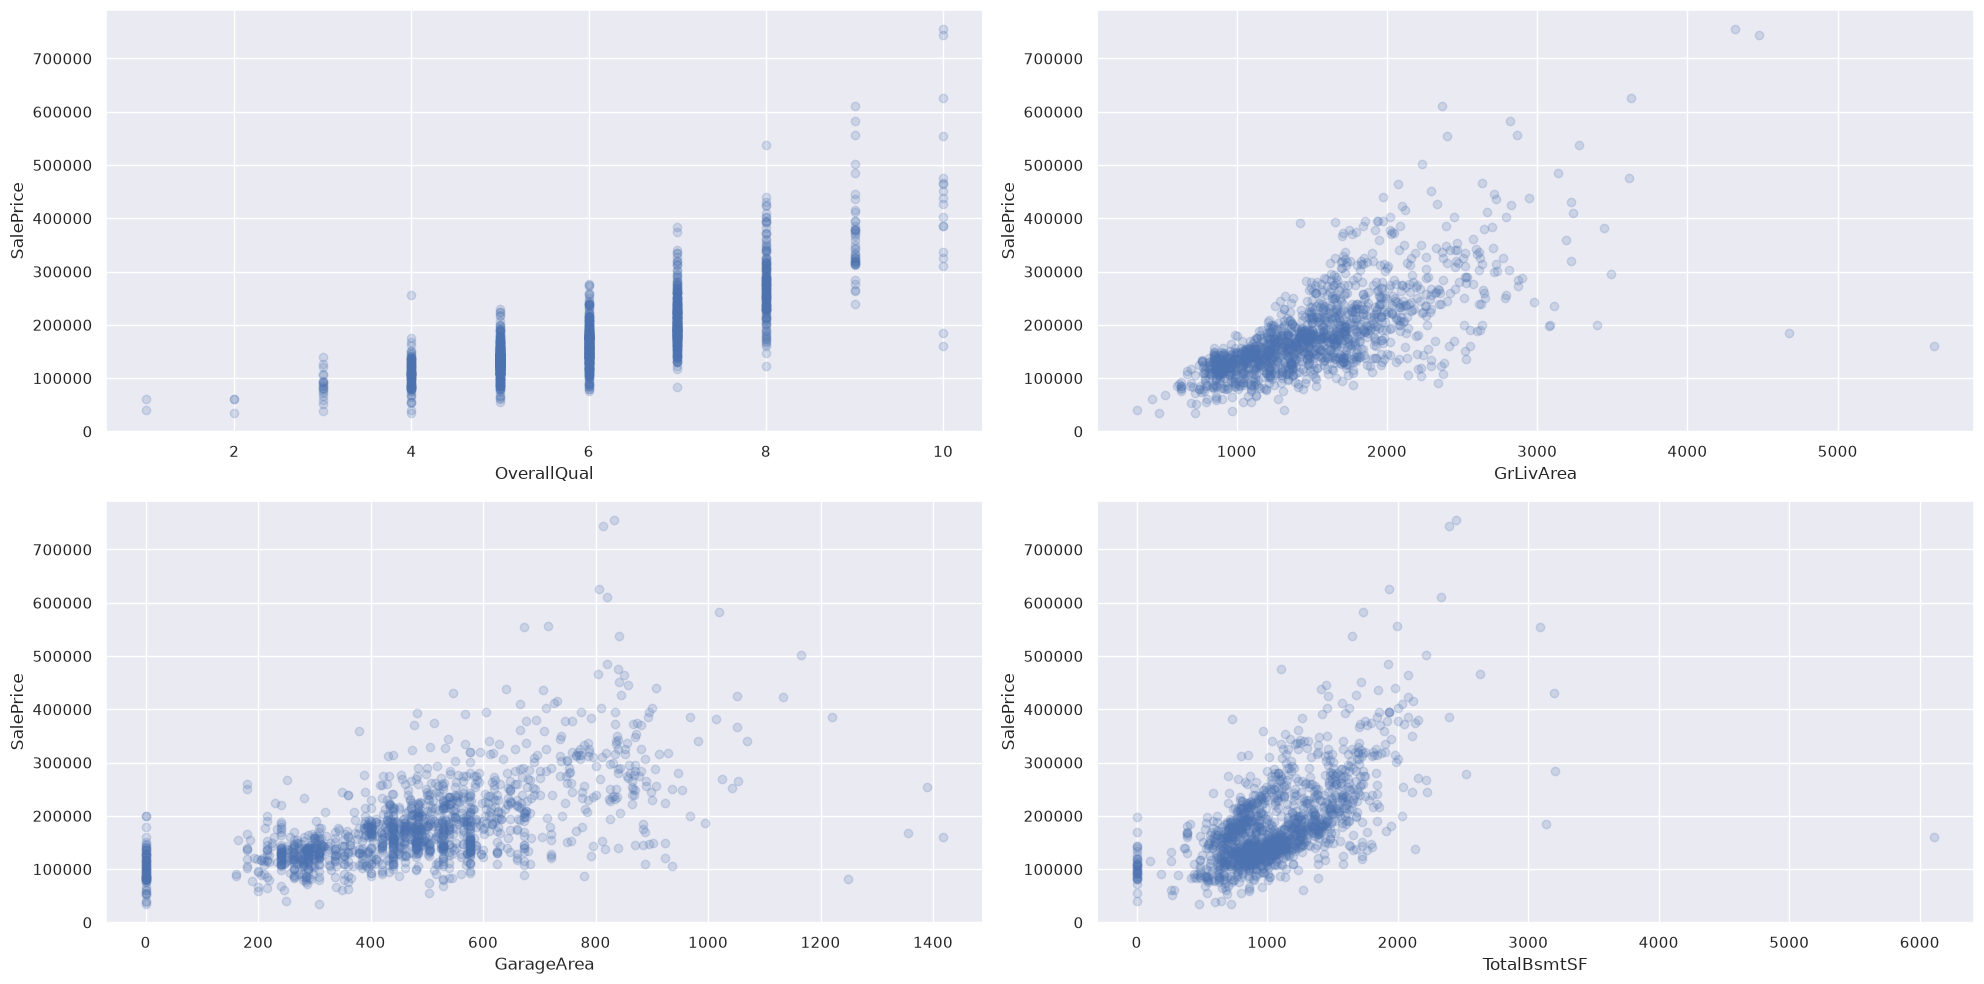

In [30]:
fig, axs = plt.subplots(figsize=(20,10), nrows=2 ,ncols=2)
for i, feature in enumerate(['OverallQual','GrLivArea', 'GarageArea', 'TotalBsmtSF']):
    axs[i//2, i%2].scatter(X_train[feature], y_train, alpha=0.2)
    axs[i//2, i%2].set_xlabel(feature)
    axs[i//2, i%2].set_ylabel('SalePrice')
plt.tight_layout()